In [1]:
# MPS safety: enable CPU fallback for unsupported ops
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
from typing import List, Tuple, Dict, Optional, Sequence, Any
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader    
import math
import json
from itertools import permutations, combinations

import numpy as np

In [2]:
import os, sys
sys.path.append('../../')

from pqcqec.utils.constants import QUBITS_FOR_GATES, QISKIT_GATES, GATE_IS_DIRECTIONAL


# Tokenizer / Encoder for Data

In [3]:
class SimpleCircuitTokenizer:
    """
    Tokenizes quantum circuit operations into unique integer IDs.

    This class creates a vocabulary of all possible 1-qubit and 2-qubit
    operations for a given gateset and number of qubits. It can then
    encode a circuit (a sequence of operations) into a list of token IDs
    and decode them back.

    Gate names are treated case-insensitively. A padding token ID can be
    specified.
    """

    def __init__(
        self,
        gateset: Sequence[str],
        num_qubits: int,
        qubits_for_gates: dict[str, int],
        undirected_gates: Sequence[str] | None = None,
    ):
        """
        Initializes the tokenizer and builds the operation vocabulary.

        Args:
            gateset: A sequence of supported gate names (e.g., ['h', 'cx']).
            num_qubits: The number of qubits in the device.
            undirected_gates: A sequence of 2-qubit gates that are
                symmetrical (e.g., 'cz'). For these, (gate, (q1, q2)) is
                the same as (gate, (q2, q1)).
            pad_id: The integer ID to reserve for padding.
        """
        if num_qubits < 1:
            raise ValueError("Number of qubits must be at least 1.")
        self.num_qubits = num_qubits

        # Normalize gate names to lowercase for case-insensitive handling
        self.gates = {g.lower() for g in gateset}
        self.undirected = {g.lower() for g in (undirected_gates or [])}
        self.qubits_for_gates = {g.lower(): qubits_for_gates[g] for g in qubits_for_gates}

        # Validate that undirected gates are part of the main gateset
        if not self.undirected.issubset(self.gates):
            unknown = self.undirected - self.gates
            raise ValueError(f"Undirected gates {unknown} are not in the main gateset.")

        # --- Build Vocabulary ---
        # The vocabulary maps (gate_name, (qubits,)) tuples to integer IDs.
        # This is built once at initialization for efficiency.

        self.pad_id = 0
        # self.unk_id = 1

        self.pad_gate = "pad"
        # self.unk_gate = "unk"

        self.pad_token = (self.pad_gate, ())
        # self.unk_token = (self.unk_gate, ())

        self.op_to_id: dict[tuple[str, tuple[int, ...]], int] = {self.pad_token: self.pad_id}
        self.id_to_op: dict[int, tuple[str, tuple[int, ...]]] = {self.pad_id: self.pad_token}

        self._build_vocab()

    @property
    def vocab_size(self) -> int:
        """Returns the total number of unique tokens, including padding."""
        return len(self.op_to_id)

    def _build_vocab(self) -> None:
        """
        Generates all 1- and 2-qubit operations using combinations/permutations
        and assigns deterministic IDs (no if-branches inside).
        """
        sorted_gates = sorted(self.gates)
        next_id = len(self.id_to_op)  # 0 is PAD
        qubits = range(self.num_qubits)
        # print(singles, directed_pairs, undirected_pairs)

        for g in sorted_gates:
            q_count = self.qubits_for_gates.get(g, None)
            qubit_tokens = list(combinations(qubits, q_count)) if g in self.undirected else list(permutations(qubits, q_count))
            for qs in qubit_tokens:
                op = (g, tuple(qs))
                self.op_to_id[op] = next_id
                self.id_to_op[next_id] = op
                next_id += 1

    def _canonicalize_op(self, gate: str, qubits: Sequence[int]) -> tuple[str, tuple[int, ...]]:
        """
        Normalizes an operation and validates its components.
        - Lowercases the gate name.
        - Sorts qubit indices for undirected gates.
        - Validates gate name, qubit count, and qubit indices.
        """
        g = gate.lower()
        if g not in self.gates:
            raise ValueError(f"Gate '{gate}' is not in the tokenizer's gateset.")

        qs = tuple(qubits)
        if not (1 <= len(qs) <= 2):
            raise ValueError(f"Only 1- and 2-qubit operations are supported, but got {len(qs)} qubits for gate '{gate}'.")
        
        for q in qs:
            if not (0 <= q < self.num_qubits):
                raise ValueError(f"Qubit index {q} is out of range for a device with {self.num_qubits} qubits.")

        if len(qs) == 2:
            if qs[0] == qs[1]:
                raise ValueError("A 2-qubit operation must act on two different qubits.")
            # For undirected gates, sort qubits to get the canonical form (e.g., (1, 2) not (2, 1))
            if g in self.undirected:
                qs = tuple(sorted(qs))
        
        return g, qs


    def encode(self, circuit: Sequence[tuple[str, Sequence[int], Any]]) -> list[int]:
        """
        Encodes a sequence of circuit operations into token IDs.

        Args:
            circuit: A list of operations, where each operation is a tuple
                     like ('gate_name', [qubit_indices], params). The params
                     are ignored.

        Returns:
            A list of integer token IDs corresponding to the operations.
        """
        token_ids = []
        for gate, qubits, *_ in circuit:
            op = self._canonicalize_op(gate, qubits)
            token_ids.append(self.op_to_id[op])
        return token_ids

    def decode(self, token_ids: Sequence[int]) -> list[list[Any]]:
        """
        Decodes a sequence of token IDs back into circuit operations.

        Args:
            token_ids: A list of integer token IDs.

        Returns:
            A list of operations in the format [['gate_name', [qubits], []]].
            Padding tokens are ignored.
        """
        circuit = []
        for token_id in token_ids:
            if token_id == self.pad_id:
                continue
            
            if token_id not in self.id_to_op:
                raise KeyError(f"Token ID {token_id} is not in the vocabulary.")
            
            gate, qubits = self.id_to_op[token_id]
            circuit.append([gate, list(qubits), []])
        return circuit

    def print_vocab(self, limit: int | None = 20) -> None:
        """Print up to `limit` vocab entries by token id (ascending).
        Pass None to print all.
        """
        for token_id in sorted(self.id_to_op.keys())[:limit]:
            gate, qubits = self.id_to_op[token_id]
            print(f"ID {token_id:3}: Gate '{gate}' on qubits {qubits}")

    def __repr__(self) -> str:
        return (
            f"CircuitTokenizer(vocab_size={self.vocab_size}, num_qubits={self.num_qubits}, "
            f"pad_id={self.pad_id}, num_gates={len(self.gates)})"
        )


In [4]:
class SimpleCircuitDataset(Dataset):
    def __init__(self, tokenizer: SimpleCircuitTokenizer, circuit_data: List):
        """
        Args:
            tokenizer: An instance of SimpleCircuitTokenizer to encode circuit operations.
            circuit_data: A list of circuits, pqc params, and the measured fidelity where each circuit is a list of operations.
                         Each operation is a tuple (gate_name, qubit_indices, params).
                         Each PQC param is of a fixed shape. 
                         Each Fidelity is a single float value <= 1.0. 
        """
        self.tokenizer = tokenizer
        self.circuit_data = circuit_data

    def __len__(self) -> int:
        return len(self.circuit_data)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            A tuple containing:
            - Encoded tokens as a tensor of shape [L], where L is the sequence length.
            - Attention mask as a tensor of shape [L], where 1 indicates valid tokens and 0 indicates padding.
        """
        circuit, params, fidelity = self.circuit_data[idx]
        input_ids = self.tokenizer.encode(circuit)  # Encode the circuit into token IDs
        attention_mask = [1 for x in input_ids if x != self.tokenizer.pad_id]  # Create an attention mask with 1s for valid tokens

        # Convert to tensors
        transformer_dict = {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long)
        }
        params_tensor = torch.tensor(params, dtype=torch.float)
        fidelity_tensor = torch.tensor(fidelity, dtype=torch.float)

        return transformer_dict, params_tensor, fidelity_tensor

# Transformer

In [5]:
# ---------------- Positional encoding (batch_first) ----------------
class PositionalEncodingBF(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)                                  # [L, C]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) # [L, 1]
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, L, C] for batch_first broadcasting
        self.register_buffer("pe", pe, persistent=False)

    def forward(self, x):  # x: [B, L, C]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# ---------------- Simple Transformer Encoder -> angle regressor ----------------
class SimpleTransformer(nn.Module):
    def __init__(self,
                 vocab_size: int,
                 out_shape: tuple,   # (K, Q, P)
                 d_model: int = 128,
                 nhead: int = 2,
                 num_encoder_layers: int = 2,
                 dim_feedforward: int = 256,
                 dropout: float = 0.1,
                 pad_id: int = 0,
                 max_len: int = 128):
        super().__init__()
        self.K, self.Q, self.P = out_shape
        self.out_dim = self.K * self.Q * self.P
        self.d_model = d_model
        self.pad_id = pad_id

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_encoder = PositionalEncodingBF(d_model, dropout, max_len=max_len)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_encoder_layers)

        self.regression_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, self.out_dim)
        )

    def forward(self, input_ids, attention_mask=None):  # [B, L] or [L]
        # Check if input is batched or singular
        is_batched = input_ids.dim() == 2

        if not is_batched:
            input_ids = input_ids.unsqueeze(0)  # Add batch dimension for singular data
            if attention_mask is not None:
                attention_mask = attention_mask.unsqueeze(0)

        # Embedding + scale
        x = self.embedding(input_ids.long()) * math.sqrt(self.d_model)  # [B, L, C]
        x = self.pos_encoder(x)

        # Key padding mask: True where padding should be ignored
        if attention_mask is None:
            pad_mask = (input_ids == self.pad_id)  # [B, L]
        else:
            pad_mask = ~attention_mask.bool()  # True where pad
        # Avoid MPS nested-tensor fast path by not passing src_key_padding_mask on MPS
        key_padding_mask = None if input_ids.device.type == 'mps' else pad_mask

        # Encoder
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)  # [B, L, C]

        # Masked mean pool over tokens
        mask = (~pad_mask).unsqueeze(-1).float()  # [B, L, 1]
        denom = mask.sum(dim=1).clamp_min(1.0)            # [B, 1]
        pooled = (x * mask).sum(dim=1) / denom            # [B, C]

        # Regress angles
        y = self.regression_head(pooled)                  # [B, K*Q*P]
        y = y.view(-1, self.K, self.Q, self.P)            # [B, K, Q, P]

        if not is_batched:
            y = y.squeeze(0)  # Remove batch dimension for singular data

        return y


# Loss Functions

In [6]:
def cosine_loss(pred_angles: torch.Tensor, target_angles: torch.Tensor) -> torch.Tensor:
    """
    Computes cosine loss between predicted and target angles.
    """
    
    cos_loss = 1 - torch.cos(pred_angles - target_angles)
    return cos_loss.mean()

# Train

In [7]:
# ----------------------------
# Train / Validate Helpers
# ----------------------------
    

@torch.no_grad()
def evaluate_epoch(model: nn.Module, dataloader, loss_fn, device: torch.device) -> float:
    model.eval()
    total_loss = 0.0
    total_batches = 0
    for batch in dataloader:
        x: Dict[str, Any]
        y, _ = None, None
        x, y, _ = batch  # transformer_dict, params_tensor, fidelity_tensor
        input_ids = x['input_ids'].to(device)
        attention_mask = x.get('attention_mask', None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)
        target = y.to(device)

        pred = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(pred, target)
        total_loss += float(loss.detach().cpu())
        total_batches += 1
    return total_loss / max(1, total_batches)

def train_epoch(model: nn.Module, dataloader, 
                optimizer: torch.optim.Optimizer, 
                loss_fn, device: torch.device, 
                grad_clip: Optional[float] = None) -> float:
    
    model.train()
    total_loss = 0.0
    total_batches = 0
    for batch in dataloader:
        x, y, _ = batch  # transformer_dict, params_tensor, fidelity_tensor
        
        
        input_ids = x['input_ids'].to(device)
        attention_mask = x.get('attention_mask', None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)
        target = y.to(device)

        # print(input_ids)
        # print(attention_mask)   
        # print(target)
        
        optimizer.zero_grad(set_to_none=True)
        pred = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(pred, target)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += float(loss.detach().cpu())
        total_batches += 1
    return total_loss / max(1, total_batches)

def train(model: nn.Module,
        train_loader,
        val_loader,
        optimizer: torch.optim.Optimizer,
        loss_fn,
        device: torch.device,
        epochs: int = 10,
        grad_clip: Optional[float] = None):
    """Train and validate the model, returning history.
    Returns: (train_losses: List[float], val_losses: List[float])
    """
    train_hist, val_hist = [], []
    for epoch in range(1, epochs + 1):
        tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, device, grad_clip)
        va_loss = evaluate_epoch(model, val_loader, loss_fn, device)
        train_hist.append(tr_loss); val_hist.append(va_loss)
        print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")
    return train_hist, val_hist


# Constants

In [8]:
PQC_GATES = ['rz', 'rx', 'rz']
DATA_PATH = '../../nogit/quaternion/uncomp_data/rzrxrz/3q_5g_5blk_data/'
GOOD_DATA_PATH = DATA_PATH + 'good_fidelity/'
BAD_DATA_PATH = DATA_PATH + 'poor_fidelity/'
CONFIG_PATH = DATA_PATH + 'config.json'

with open(CONFIG_PATH, 'r') as f:
    CONFIG = json.load(f)

print(CONFIG)

HAS_UNCOMP = CONFIG.get("add_uncomp", True)
NUM_QUBITS = CONFIG.get("qubits", 3)[0]
NUM_GATES = CONFIG.get("gates", 4)[0] * (2 if HAS_UNCOMP else 1)
GATE_BLOCKS = CONFIG.get("gate_blocks", 4)
VALID_GATES = list(CONFIG.get("gate_dist", QISKIT_GATES).keys())
print(f"Using {NUM_QUBITS} qubits, {NUM_GATES} gates, {GATE_BLOCKS} gate blocks, {VALID_GATES} valid gates. ",
      f"The dataset has {'uncomputed' if HAS_UNCOMP else 'regular'} states.")


PAD_ID = 0
UNDIRECTED_GATES = [gate for gate in VALID_GATES if not GATE_IS_DIRECTIONAL.get(gate, False)]
print(UNDIRECTED_GATES)

TRAIN_SZ = 0.8
VAL_SZ = 0.1
TEST_SZ = 0.1
BATCH_SIZE = 64

LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-2

D_MODEL = 128
NUM_HEADS = 2
NUM_ENCODER_LAYERS = 2
DIM_FEEDFORWARD = 256
DROPOUT = 0.2
MAX_LEN = 128

EPOCHS = 100
GRAD_CLIP = 1.0

{'config': 'nogit/quaternion/uncomp_data/rzrxrz/3q_5g_5blk_data/config.json', 'qubit_range': [3], 'gate_range': [5], 'pqc_blocks': 1, 'gate_blocks': 5, 'figure_output': 'nogit/quaternion/uncomp_data/rzrxrz', 'epochs': 3, 'num_data': 2500, 'num_test': 50, 'seed': '1000', 'gate_dist': {'h': 0.5, 'cx': 0.25, 'x': 0.25}, 'noise_dist': {'x_rad': 0.0314, 'z_rad': 0.0, 'delta_x': 0.0, 'delta_z': 0.0}, 'gpu': False, 'batch': 10, 'force': True, 'redo': False, 'mp_cores': 0, 'uncomp': True, 'qubits': [3], 'gates': [5], 'device': 'cpu'}
Using 3 qubits, 10 gates, 5 gate blocks, ['h', 'cx', 'x'] valid gates.  The dataset has uncomputed states.
['h', 'x']


# Load Data

In [9]:

good_data = []
poor_data = []

for filename in os.listdir(GOOD_DATA_PATH):
    with open(GOOD_DATA_PATH + filename, 'r') as f:
        token_dict = json.load(f)
        good_data.append((token_dict['base_circuit_tokens'], token_dict['pqc_params'], token_dict['fidelity']))
        f.close()

for filename in os.listdir(BAD_DATA_PATH):
    with open(BAD_DATA_PATH + filename, 'r') as f:
        token_dict = json.load(f)
        poor_data.append((token_dict['base_circuit_tokens'], token_dict['pqc_params'], token_dict['fidelity']))
        f.close()

print(f"Number of good data samples: {len(good_data)}")
print(f"Number of poor data samples: {len(poor_data)}")

Number of good data samples: 1001
Number of poor data samples: 0


In [10]:
qc_tokenizer = SimpleCircuitTokenizer(gateset=VALID_GATES, 
                                      num_qubits=NUM_QUBITS, 
                                      undirected_gates=UNDIRECTED_GATES, 
                                      qubits_for_gates=QUBITS_FOR_GATES)


In [11]:
qc_good_dataset = SimpleCircuitDataset(qc_tokenizer, good_data)
qc_poor_dataset = SimpleCircuitDataset(qc_tokenizer, poor_data)

print(f"Good dataset size: {len(qc_good_dataset)}")
print(f"Poor dataset size: {len(qc_poor_dataset)}")

Good dataset size: 1001
Poor dataset size: 0


In [12]:

total_size = len(qc_good_dataset)
train_size = int(TRAIN_SZ * total_size)
val_size = int(VAL_SZ * total_size)
test_size = total_size - train_size - val_size
qc_train_dataset, qc_val_dataset, qc_test_dataset = torch.utils.data.random_split(qc_good_dataset, [train_size, val_size, test_size])

qc_train_dataloader = DataLoader(qc_train_dataset, batch_size=BATCH_SIZE, shuffle=True, )
qc_val_dataloader = DataLoader(qc_val_dataset, batch_size=BATCH_SIZE, shuffle=False, )
qc_test_dataloader = DataLoader(qc_test_dataset, shuffle=False, )




In [13]:
simple_model = SimpleTransformer(vocab_size=qc_tokenizer.vocab_size,
                                  out_shape=(int(NUM_GATES//GATE_BLOCKS), NUM_QUBITS, len(PQC_GATES)),
                                  d_model=D_MODEL,
                                  nhead=NUM_HEADS,
                                  num_encoder_layers=NUM_ENCODER_LAYERS,
                                  dim_feedforward=DIM_FEEDFORWARD,
                                  dropout=DROPOUT,
                                  pad_id=qc_tokenizer.pad_id,
                                  max_len=MAX_LEN)

simple_model


SimpleTransformer(
  (embedding): Embedding(13, 128, padding_idx=0)
  (pos_encoder): PositionalEncodingBF(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (regression_head): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=128, out_featur

In [14]:

optimizer = torch.optim.AdamW(simple_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


In [15]:
device_str = 'cuda' if torch.cuda.is_available() else ('mps' if torch.mps.is_available() else 'cpu')
device = torch.device(device_str)

print(f'Using device : {device}')

simple_model.to(device)

loss_fn = cosine_loss
# loss_fn = nn.MSELoss()

train_hist, val_hist = train(
    model=simple_model,
    train_loader=qc_train_dataloader,
    val_loader=qc_val_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=EPOCHS,
    grad_clip=GRAD_CLIP
)

Using device : mps
Epoch 01 | train_loss=0.9325 | val_loss=0.8955
Epoch 02 | train_loss=0.9149 | val_loss=0.8811
Epoch 03 | train_loss=0.8922 | val_loss=0.8572
Epoch 04 | train_loss=0.8591 | val_loss=0.8247
Epoch 05 | train_loss=0.8183 | val_loss=0.7869
Epoch 06 | train_loss=0.7762 | val_loss=0.7473
Epoch 07 | train_loss=0.7330 | val_loss=0.7070
Epoch 08 | train_loss=0.6887 | val_loss=0.6668
Epoch 09 | train_loss=0.6436 | val_loss=0.6282
Epoch 10 | train_loss=0.6024 | val_loss=0.5919
Epoch 11 | train_loss=0.5639 | val_loss=0.5581
Epoch 12 | train_loss=0.5278 | val_loss=0.5284
Epoch 13 | train_loss=0.4978 | val_loss=0.5032
Epoch 14 | train_loss=0.4705 | val_loss=0.4831
Epoch 15 | train_loss=0.4523 | val_loss=0.4680
Epoch 16 | train_loss=0.4377 | val_loss=0.4574
Epoch 17 | train_loss=0.4265 | val_loss=0.4503
Epoch 18 | train_loss=0.4183 | val_loss=0.4459
Epoch 19 | train_loss=0.4148 | val_loss=0.4431
Epoch 20 | train_loss=0.4122 | val_loss=0.4419
Epoch 21 | train_loss=0.4119 | val_loss=0

# Plot Loss

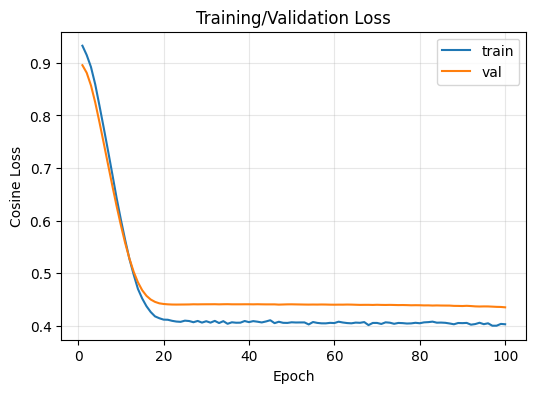

In [16]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_hist) + 1) if 'train_hist' in globals() else []
plt.figure(figsize=(6,4))
if epochs:
    plt.plot(epochs, train_hist, label='train')
    plt.plot(epochs, val_hist, label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Cosine Loss')
    plt.title('Training/Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    print('Run the training cell first to populate train_hist/val_hist.')
plt.show()


# Testing Model with Zero State

In [17]:
def interleave_tensor_pqc_in_circuit(base_ops:list, qubits:int, blocks:int, pqc_gates:list, params:list):
    """Interleave PQC operations into the base circuit."""
    interleaved_circuit = []
    # print(params.shape)
    for i, op in enumerate(base_ops):
        # print(i, op)
        interleaved_circuit.append(op)
        if (i + 1) % blocks == 0:
            k = (i + 1) // blocks - 1
            # print(f"Interleaving PQC operations for block {k}")
            for q in range(qubits):
                for j, g in enumerate(pqc_gates):
                    # print(g, q, (k,q,j), params[k, q, j])
                    interleaved_circuit.append((g, [q], params[k, q, j].detach().numpy()))
    return interleaved_circuit

In [18]:
from pqcqec.noise.simple_noise import PennylaneNoisyGates
from pqcqec.simulate.simulate import run_circuit_with_noise_model
from pqcqec.training.jax_loss_functions import jax_pure_state_fidelity

import jax.numpy as jnp

noise_model = PennylaneNoisyGates(0.0314,0,0,0)
no_noise_model = PennylaneNoisyGates(0,0,0,0)
# NUM_QUBITS = 5
ZERO_STATE = jnp.zeros((2 ** NUM_QUBITS,), dtype=jnp.complex64).at[0].set(1.0)


In [19]:
simple_model.eval()  # Set the model to evaluation mode
test_fid_model = []
test_fid_default = []
test_fid_data = []
for i, data in enumerate(qc_test_dataloader):

    data, params, fid = data

    input_ids = data['input_ids'].to(device)
    attention_mask = data['attention_mask'].to(device)
    pqc_params = params[0]

    circuit_ops = qc_tokenizer.decode(input_ids[0].cpu().numpy().tolist())
    # circuit_ops = [(op[0], op[1], []) for op in circuit_ops]  # Add params placeholder from the circuit ops
    pqc_circuit = interleave_tensor_pqc_in_circuit(circuit_ops, NUM_QUBITS, GATE_BLOCKS, PQC_GATES, pqc_params)


    pred_theta = simple_model(input_ids, attention_mask=attention_mask)[0].to('cpu')
    # print(pred_theta)
    circuit_interleaved = interleave_tensor_pqc_in_circuit(circuit_ops, NUM_QUBITS, GATE_BLOCKS, PQC_GATES, pred_theta)

    if HAS_UNCOMP:
        ideal_out_state = ZERO_STATE
    else:
        ideal_out_state = run_circuit_with_noise_model(circuit_ops, ZERO_STATE, no_noise_model, NUM_QUBITS)

    measured_modelPQC = run_circuit_with_noise_model(circuit_interleaved, ZERO_STATE, noise_model, NUM_QUBITS)
    measured_defaultPQC = run_circuit_with_noise_model(pqc_circuit, ZERO_STATE, noise_model, NUM_QUBITS)

    # print(ZERO_STATE)
    # print(measured_modelPQC)

    fidelity_modelPQC = jax_pure_state_fidelity(ideal_out_state, measured_modelPQC)
    fidelity_defaultPQC = jax_pure_state_fidelity(ideal_out_state, measured_defaultPQC)

    test_fid_model.append(fidelity_modelPQC)
    test_fid_default.append(fidelity_defaultPQC)
    test_fid_data.append(fid[0].item())

    # print(f"Fidelity (Model PQC): {fidelity_modelPQC:.4e}, Fidelity (Default PQC): {fidelity_defaultPQC:.4e}")

In [20]:
print(f"Net Fidelity (Model PQC): {np.mean(test_fid_model):.4e}, Net Fidelity (Default PQC): {np.mean(test_fid_default):.4e}, Net Fidelity (Data): {np.mean(test_fid_data):.4e}")

Net Fidelity (Model PQC): 9.4200e-01, Net Fidelity (Default PQC): 9.9988e-01, Net Fidelity (Data): 9.9988e-01


(array([ 1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  3.,  3.,  7.,  7.,
         3.,  4.,  8., 12., 12., 16., 24.]),
 array([0.72157955, 0.73522645, 0.74887335, 0.76252019, 0.77616709,
        0.789814  , 0.8034609 , 0.8171078 , 0.83075464, 0.84440154,
        0.85804844, 0.87169534, 0.88534224, 0.89898908, 0.91263598,
        0.92628288, 0.93992978, 0.95357668, 0.96722353, 0.98087043,
        0.99451733]),
 <BarContainer object of 20 artists>)

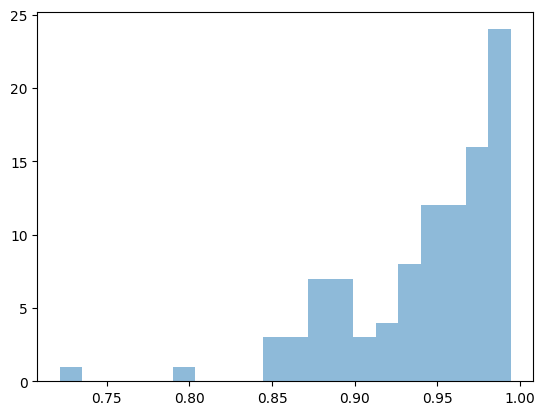

In [21]:
plt.hist(test_fid_model, bins=20, alpha=0.5, label='Model PQC')

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  1.,  7.,  0.,  0.,  0., 92.]),
 array([0.99581575, 0.99602497, 0.99623418, 0.99644339, 0.9966526 ,
        0.99686182, 0.99707103, 0.99728024, 0.99748945, 0.99769866,
        0.99790788, 0.99811709, 0.9983263 , 0.99853551, 0.99874473,
        0.99895394, 0.99916315, 0.99937236, 0.99958158, 0.99979079,
        1.        ]),
 <BarContainer object of 20 artists>)

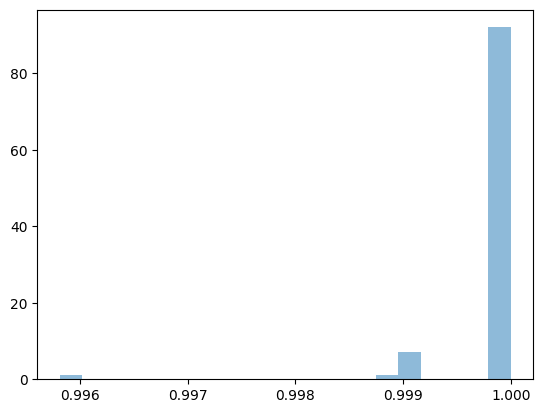

In [22]:
plt.hist(test_fid_default, bins=20, alpha=0.5, label='Default PQC')

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  9.,  0.,  0.,  0., 91.]),
 array([0.99587554, 0.99608176, 0.99628798, 0.99649421, 0.99670043,
        0.99690665, 0.99711288, 0.9973191 , 0.99752532, 0.99773155,
        0.99793777, 0.99814399, 0.99835021, 0.99855644, 0.99876266,
        0.99896888, 0.99917511, 0.99938133, 0.99958755, 0.99979378,
        1.        ]),
 <BarContainer object of 20 artists>)

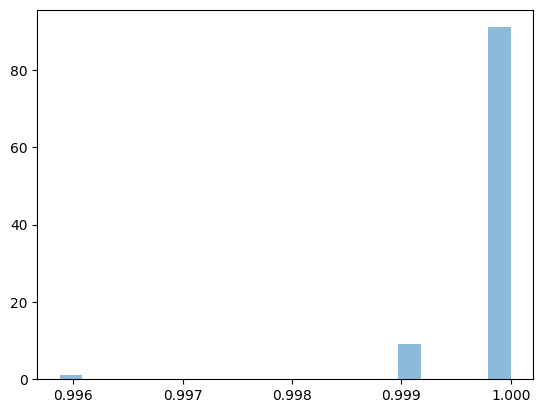

In [23]:
plt.hist(test_fid_data, bins=20, alpha=0.5, label='Data PQC')